In [ ]:
import os
import sys
import pandas as pd

# ==============================================================================
# 1. DYNAMIC DIRECTORY ALIGNMENT
# ==============================================================================
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

# Inject project root into Python path so it can find 'src'
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"📁 Notebook directory: {notebook_dir}")
print(f"🚀 Project Root: {project_root}")

# Prevent pandas truncation
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# ==============================================================================
# 2. IMPORT MODULES FROM SRC
# ==============================================================================
try:
    from src.data_loader import load_raw_csv, clean_conv_pct
    from src.strikers import find_breakout_strikers
    print("✅ src modules successfully imported!")
except ModuleNotFoundError as e:
    print(f"❌ IMPORT ERROR: {e}")

# ==============================================================================
# 3. ROUTED DATA LOADING (Navigating data -> raw -> file)
# ==============================================================================
filename = "all_mplayers_y1.csv"

# Added "raw" to step directly into your subfolder
csv_filename = os.path.join(project_root, "data", "raw", filename)

if os.path.exists(csv_filename):
    print(f"📊 Found raw data file at: {csv_filename}")
    
    raw_df = load_raw_csv(csv_filename)
    cleaned_df = clean_conv_pct(raw_df)
    
    # Run the TOPSIS Engine
    print("🤖 Processing Multi-Criteria TOPSIS Optimization...")
    striker_report = find_breakout_strikers(cleaned_df, min_minutes=700, max_minutes=2000)
    
    # Save the output file one level up in 'data' to keep 'raw' pristine
    output_path = os.path.join(project_root, "data", "global_breakout_strikers.csv")
    striker_report.to_csv(output_path, index=False)
    print(f"💾 Optimized report saved to: {output_path}")
    
    # Display results
    display(striker_report)
else:
    print(f"❌ DATA FILE NOT FOUND at: {csv_filename}")
    print(f"Please double check your file is inside: {os.path.join(project_root, 'data', 'raw')}")

📁 Notebook directory: d:\Summer Coding Projects\fm26-analytics\notebooks
🚀 Project Root: d:\Summer Coding Projects\fm26-analytics
✅ src modules successfully imported!
📊 Found raw data file at: d:\Summer Coding Projects\fm26-analytics\data\raw\all_wplayers_y1.csv
🤖 Processing Multi-Criteria TOPSIS Optimization...
💾 Optimized report saved to: d:\Summer Coding Projects\fm26-analytics\data\global_breakout_strikers.csv


,Player,Club,Age,Minutes,Goals per 90 minutes,xG/90,Conv %,Scouting_Index_Score
0,Ada Hegerberg,OL,30,1478,1.2,0.5,28,86.438312
1,Mayra Ramírez,Chelsea,27,1452,1.0,0.7,17,79.056329
2,Eileen Campbell,Union Berlin,25,1645,0.8,0.3,30,63.178750
3,Rikke Madsen,HB Køge,28,1528,0.8,0.4,19,62.114332
4,Elisabeth Terland,Man Utd,24,1226,0.9,0.4,19,61.070041
5,Barbra Banda,Orlando Pride,26,1157,0.9,0.4,19,59.426001
6,Signe Bruun,R. Madrid,28,745,1.0,0.5,20,54.327984
7,Mama Diop,Strasbourg,31,703,1.0,0.5,26,53.895321
8,Vivianne Miedema,Man City,29,1314,0.7,0.5,14,53.688773
9,Michelle Heyman,Canberra United,37,1040,0.8,0.4,23,53.099697


In [ ]:
import os
import sys
import pandas as pd

# ==============================================================================
# 1. PATH SETUP & PACKAGING CHECKS
# ==============================================================================
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))

if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_raw_csv, clean_conv_pct
from src.strikers import find_breakout_strikers

# ==============================================================================
# 2. DEFINE AND LOAD HISTORICAL CSV FILES
# ==============================================================================
season1_filename = "all_mplayers_y1.csv"  
season2_filename = "all_mplayers_y2.csv"  

s1_path = os.path.join(project_root, "data", "raw", season1_filename)
s2_path = os.path.join(project_root, "data", "raw", season2_filename)

if not os.path.exists(s1_path) or not os.path.exists(s2_path):
    print("❌ ERROR: One or both historical files could not be found.")
else:
    print("📊 Loading and preparing historical data...")
    season1_df = clean_conv_pct(load_raw_csv(s1_path))
    season2_df = clean_conv_pct(load_raw_csv(s2_path))
    
    print(f"✅ Data processed! S1 ({len(season1_df)} players) | S2 ({len(season2_df)} players)")

    # ==============================================================================
    # 3. GENERATE SCORES FOR BOTH SEASONS
    # ==============================================================================
    print("🔮 Calculating Season 1 TOPSIS Index Scores...")
    s1_predictions = find_breakout_strikers(season1_df, min_minutes=700, max_minutes=2000)
    s1_scores = s1_predictions[['Player', 'Scouting_Index_Score']].copy()
    s1_scores.rename(columns={'Scouting_Index_Score': 'S1_Index_Score'}, inplace=True)

    print("🔮 Calculating Season 2 TOPSIS Index Scores...")
    # We open up max_minutes to 99999 so full-season starters aren't filtered out of the S2 ranking math
    s2_predictions = find_breakout_strikers(season2_df, min_minutes=700, max_minutes=99999)
    s2_scores = s2_predictions[['Player', 'Scouting_Index_Score']].copy()
    s2_scores.rename(columns={'Scouting_Index_Score': 'S2_Index_Score'}, inplace=True)

    # ==============================================================================
    # 4. GRAB RAW S2 EVOLUTION & MERGE EVERYTHING
    # ==============================================================================
    s2_natural_evolution = season2_df[season2_df['Minutes'] >= 900][['Player', 'Club', 'Minutes', 'Goals per 90 minutes', 'xG/90']].copy()
    s2_natural_evolution.rename(columns={
        'Minutes': 'S2_Minutes',
        'Goals per 90 minutes': 'S2_Actual_G90',
        'xG/90': 'S2_Actual_xG90'
    }, inplace=True)

    # Merge Season 1 predictions with their Season 2 playing stats
    validation_df = pd.merge(s1_scores, s2_natural_evolution, on='Player', how='inner')
    
    # Left-join the Season 2 algorithm scores so we can compare the evaluation shift
    validation_df = pd.merge(validation_df, s2_scores, on='Player', how='left')

    # Reorder columns logically to put the two scouting index scores right next to each other
    column_order = [
        'Player', 'S1_Index_Score', 'S2_Index_Score', 'Club', 
        'S2_Minutes', 'S2_Actual_G90', 'S2_Actual_xG90'
    ]
    validation_df = validation_df[column_order]
    validation_df = validation_df.sort_values(by='S1_Index_Score', ascending=False).reset_index(drop=True)

    # ==============================================================================
    # 5. REPORT CARD OUTPUT
    # ==============================================================================
    if len(validation_df) < 5:
        print("⚠️ The test pool is too small to calculate reliable stats.")
    else:
        correlation = validation_df['S1_Index_Score'].corr(validation_df['S2_Actual_G90'])
        
        print("\n" + "="*75)
        print("📊 NATURAL EVOLUTION ACCURACY REPORT (WITH SEASON-OVER-SEASON SCORES)")
        print("="*75)
        print(f"👥 Total low-minute targets AI naturally utilized in S2: {len(validation_df)}")
        print(f"📈 S1 Model Score to Future Goal Correlation Rate: {correlation:.2f}")
        print("="*75 + "\n")
        
        print("📋 Top 50 Predictions Tracking Sheet:")
        pd.set_option('display.max_rows', 55)
        display(validation_df.head(50))

❌ ERROR: One or both historical files could not be found.


🛠️ Engineering normalized performance features from raw columns...
✅ Womens league rows: 0
✅ Mens league rows: 1478
✅ Matrix built. Mapped 1478 historical player records across 2 league(s).

🤖 CROSS-VALIDATED ENGINE REPORT (5-fold)
📈 R² across folds:   [0.7  0.78 0.77 0.73 0.7 ]
   Mean R²:           0.74  (± 0.03)
📉 RMSE across folds: [0.089 0.085 0.088 0.089 0.096]
   Mean RMSE:         0.089 Goals/90 (± 0.004)

📏 NAIVE BASELINE (predict next season = this season)
   Baseline RMSE: 0.108 Goals/90
   Baseline R²:   0.62

   → RF improves RMSE by 17.0% vs. just assuming no change year-over-year.
   If this number is small or negative, the model isn't adding much beyond 'players keep scoring at roughly their existing rate'.

🤖 SINGLE HOLD-OUT REPORT (for reference only)
📉 Model Error (RMSE): 0.087 Goals/90 variance
📈 Variance Explained (R² Score): 0.71

📋 RANKED GOALSCORER PATTERNS (By Error Reduction Weight):
This breaks down exactly which Season 1 features (and league) carry the highe

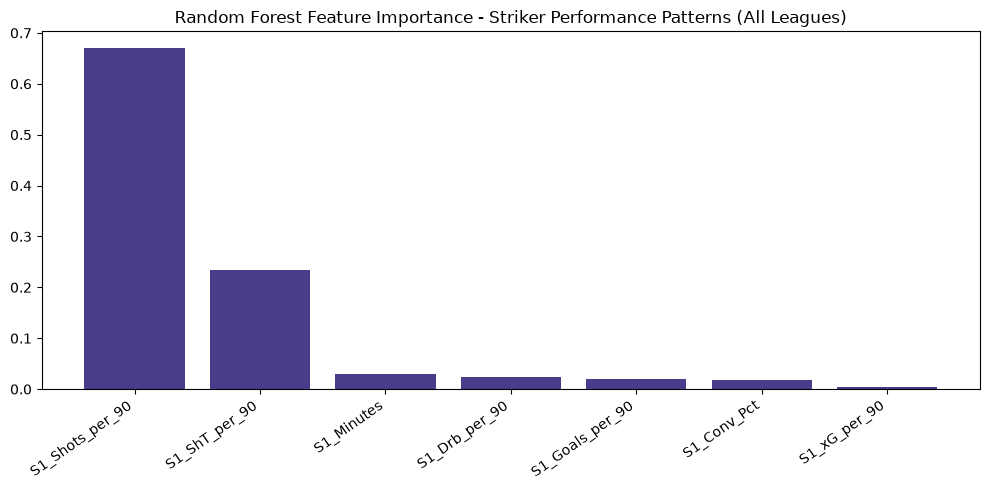

In [3]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ==============================================================================
# 0. HELPER: CLEAN CONV % (handles "23.4%" strings or already-numeric columns)
# ==============================================================================
def clean_conv_pct_numeric(series, fallback=12.0):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace('%', '', regex=False),
            errors='coerce'
        ).fillna(fallback)
    return series.fillna(fallback)


# ==============================================================================
# 1. FEATURE ENGINEERING BASED ON YOUR EXACT SCHEMA
# ==============================================================================
print("\U0001F6E0\uFE0F Engineering normalized performance features from raw columns...")

def prepare_ml_features(df, season_label, league_label, min_minutes=450):
    df_copy = df.copy()

    # Guard against division-by-zero / tiny-sample noise in per-90 stats
    df_copy = df_copy[df_copy['Minutes'] >= min_minutes].copy()

    # Standardize raw volumes into rate-metrics per 90 minutes
    df_copy['Shots_per_90'] = (df_copy['Shots'] / df_copy['Minutes']) * 90
    df_copy['ShT_per_90'] = (df_copy['ShT'] / df_copy['Minutes']) * 90

    # Clean Conv % so it's numeric before it ever reaches the model
    df_copy['Conv %'] = clean_conv_pct_numeric(df_copy['Conv %'])

    # Tag which league this row came from (used as a one-hot feature later)
    df_copy['League'] = league_label

    keep_cols = {
        'Player': 'Player',
        'League': 'League',
        'Minutes': f'{season_label}_Minutes',
        'Conv %': f'{season_label}_Conv_Pct',
        'Goals per 90 minutes': f'{season_label}_Goals_per_90',
        'xG/90': f'{season_label}_xG_per_90',
        'Drb/90': f'{season_label}_Drb_per_90',
        'Shots_per_90': f'{season_label}_Shots_per_90',
        'ShT_per_90': f'{season_label}_ShT_per_90'
    }

    return df_copy[list(keep_cols.keys())].rename(columns=keep_cols)


def build_league_ml_df(season1_df, season2_df, league_label):
    """Build the merged S1-features -> S2-target dataframe for one league."""
    s1_feat = prepare_ml_features(season1_df, 'S1', league_label)

    s2_stable = season2_df[season2_df['Minutes'] >= 900].copy()
    s2_target = s2_stable[['Player', 'Goals per 90 minutes']].rename(
        columns={'Goals per 90 minutes': 'Target_S2_G90'}
    )

    merged = pd.merge(s1_feat, s2_target, on='Player', how='inner').dropna()
    return merged


# ==============================================================================
# 2. LOAD WOMEN'S LEAGUE DATA (already loaded as season1_df / season2_df above)
#    + MEN'S LEAGUE DATA (new CSVs)
# ==============================================================================
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_raw_csv, clean_conv_pct

# --- File locations -----------------------------------------------------
# NOTE: double check "all_mplayers_y2.csv" for the women's S2 file below —
# if that's actually meant to be "all_wplayers_y2.csv", fix it here.
league_files = {
    'Womens': ("all_wplayers_y1.csv", "all_mplayers_y2.csv"),
    'Mens':   ("all_mplayers_y1.csv", "all_mplayers_y2.csv"),
}

raw_dir = os.path.join(project_root, "data", "raw")

frames = []
for league_label, (s1_filename, s2_filename) in league_files.items():
    s1_path = os.path.join(raw_dir, s1_filename)
    s2_path = os.path.join(raw_dir, s2_filename)

    if os.path.exists(s1_path) and os.path.exists(s2_path):
        s1_df = clean_conv_pct(load_raw_csv(s1_path))
        s2_df = clean_conv_pct(load_raw_csv(s2_path))

        league_ml_df = build_league_ml_df(s1_df, s2_df, league_label=league_label)
        frames.append(league_ml_df)
        print(f"\u2705 {league_label} league rows: {len(league_ml_df)}")
    else:
        print(f"\u26A0\uFE0F {league_label} CSVs not found at expected paths:\n   {s1_path}\n   {s2_path}")

if not frames:
    raise FileNotFoundError("No league data files were found in data/raw/. Check filenames above.")

# Combine leagues
ml_df_raw = pd.concat(frames, ignore_index=True)

# One-hot encode the League feature so the model can learn league-specific baselines
ml_df = pd.get_dummies(ml_df_raw, columns=['League'], drop_first=True)

ml_feature_names = [c for c in ml_df.columns if c not in ('Player', 'Target_S2_G90')]

X = ml_df[ml_feature_names]
y = ml_df['Target_S2_G90']

print(f"\u2705 Matrix built. Mapped {X.shape[0]} historical player records across {len(frames)} league(s).")

if X.shape[0] < 30:
    print(
        f"\u26A0\uFE0F  WARNING: Only {X.shape[0]} rows in the training set. "
        "With this few samples, R\u00b2/RMSE and feature importances will be "
        "high-variance and should be treated as directional, not definitive."
    )

# ==============================================================================
# 3. MODEL TRAINING & VALIDATION
# ==============================================================================

# --- 3a. Cross-validated estimate (more stable than a single split on small data) ---
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)

cv_r2 = cross_val_score(cv_model, X, y, cv=cv, scoring='r2')
cv_rmse = -cross_val_score(cv_model, X, y, cv=cv, scoring='neg_root_mean_squared_error')

print("\n" + "=" * 50)
print("\U0001F916 CROSS-VALIDATED ENGINE REPORT (5-fold)")
print("=" * 50)
print(f"\U0001F4C8 R\u00b2 across folds:   {np.round(cv_r2, 2)}")
print(f"   Mean R\u00b2:           {cv_r2.mean():.2f}  (\u00b1 {cv_r2.std():.2f})")
print(f"\U0001F4C9 RMSE across folds: {np.round(cv_rmse, 3)}")
print(f"   Mean RMSE:         {cv_rmse.mean():.3f} Goals/90 (\u00b1 {cv_rmse.std():.3f})")
print("=" * 50 + "\n")

# --- NAIVE BASELINE: "next season G90 = this season G90" (no model at all) ---
naive_pred = X['S1_Goals_per_90']
naive_rmse = np.sqrt(mean_squared_error(y, naive_pred))
naive_r2 = r2_score(y, naive_pred)

print("=" * 50)
print("\U0001F4CF NAIVE BASELINE (predict next season = this season)")
print("=" * 50)
print(f"   Baseline RMSE: {naive_rmse:.3f} Goals/90")
print(f"   Baseline R\u00b2:   {naive_r2:.2f}")
print(f"\n   \u2192 RF improves RMSE by "
      f"{(naive_rmse - cv_rmse.mean()) / naive_rmse * 100:.1f}% vs. just assuming "
      f"no change year-over-year.")
print("   If this number is small or negative, the model isn't adding much "
      "beyond 'players keep scoring at roughly their existing rate'.")
print("=" * 50 + "\n")

# --- 3b. Single train/test split, kept for the importance plot below ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestRegressor(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 50)
print("\U0001F916 SINGLE HOLD-OUT REPORT (for reference only)")
print("=" * 50)
print(f"\U0001F4C9 Model Error (RMSE): {rmse:.3f} Goals/90 variance")
print(f"\U0001F4C8 Variance Explained (R\u00b2 Score): {r2:.2f}")
print("=" * 50 + "\n")

# ==============================================================================
# 4. EXTRACTION OF MATHEMATICAL PATTERNS
# ==============================================================================
final_model = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42)
final_model.fit(X, y)

importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("\U0001F4CB RANKED GOALSCORER PATTERNS (By Error Reduction Weight):")
print("This breaks down exactly which Season 1 features (and league) carry the highest predictive signal.")
print("-" * 75)
for f in range(X.shape[1]):
    print(f"{f + 1}. Feature: {X.columns[indices[f]]:<25} | Weight Impact: {importances[indices[f]]*100:.2f}%")
print("-" * 75)
print(
    "Note: Random Forest importances split credit unevenly among correlated "
    "features (e.g. Goals/90, xG/90, Shots/90 tend to move together). Treat "
    "the ranking as 'this cluster of related stats matters', not a precise "
    "ranking of independent causes. The League_Mens/League_Womens flag (if "
    "present) tells you whether the model thinks league context shifts the "
    "baseline goal rate on its own."
)

# Output pattern visualization plot
plt.figure(figsize=(10, 5))
plt.title("Random Forest Feature Importance - Striker Performance Patterns (All Leagues)")
plt.bar(range(X.shape[1]), importances[indices], align="center", color='darkslateblue')
plt.xticks(range(X.shape[1]), [X.columns[i] for i in indices], rotation=35, ha='right')
plt.tight_layout()
plt.show()


In [5]:
import os
import sys
import pandas as pd
import numpy as np

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_raw_csv, clean_conv_pct
from src.scouting_engine import train_future_g90_model, find_active_breakouts

# ==============================================================================
# 1. LOAD HISTORICAL Y1 -> Y2 PAIRS FOR BOTH LEAGUES (for training the ML model)
# ==============================================================================
raw_dir = os.path.join(project_root, "data", "raw")

league_files = {
    'Womens': ("all_wplayers_y1.csv", "all_wplayers_y2.csv"),  # double-check y2 filename
    'Mens':   ("all_mplayers_y1.csv", "all_mplayers_y2.csv"),
}

league_history = {}
for league_label, (s1_name, s2_name) in league_files.items():
    s1_path = os.path.join(raw_dir, s1_name)
    s2_path = os.path.join(raw_dir, s2_name)

    if os.path.exists(s1_path) and os.path.exists(s2_path):
        league_history[league_label] = (
            clean_conv_pct(load_raw_csv(s1_path)),
            clean_conv_pct(load_raw_csv(s2_path)),
        )
        print(f"\u2705 Loaded {league_label} history.")
    else:
        print(f"\u26A0\uFE0F Skipping {league_label}: files not found "
              f"({s1_path}, {s2_path}). Will train without this league.")

if not league_history:
    raise FileNotFoundError("No league history files found \u2014 check filenames/paths in league_files.")

# ==============================================================================
# 2. HOLD OUT A "FAKE YEAR 3" SET OF PLAYERS BEFORE TRAINING
# ==============================================================================
# To honestly test the model, we set aside a random subset of players whose
# y1->y2 transition the model NEVER sees during training. Predicting their
# y2 outcome from y1 then acts as a stand-in for an unseen future season.
HOLDOUT_FRAC = 0.2
rng = np.random.default_rng(42)

train_history = {}
holdout_history = {}

for league_label, (s1_df, s2_df) in league_history.items():
    players = s1_df['Player'].unique()
    n_holdout = max(1, int(len(players) * HOLDOUT_FRAC))
    holdout_players = set(rng.choice(players, size=n_holdout, replace=False))

    train_s1 = s1_df[~s1_df['Player'].isin(holdout_players)].copy()
    train_s2 = s2_df[~s2_df['Player'].isin(holdout_players)].copy()
    hold_s1 = s1_df[s1_df['Player'].isin(holdout_players)].copy()
    hold_s2 = s2_df[s2_df['Player'].isin(holdout_players)].copy()

    train_history[league_label] = (train_s1, train_s2)
    holdout_history[league_label] = (hold_s1, hold_s2)

    print(f"{league_label}: {len(players) - len(holdout_players)} players for training, "
          f"{len(holdout_players)} held out as 'fake year 3' test set.")

# ==============================================================================
# 3. TRAIN THE FUTURE-G90 PREDICTOR ON THE TRAINING SUBSET ONLY
# ==============================================================================
model, feature_cols, n_train = train_future_g90_model(train_history)
print(f"\n\u2705 Trained on {n_train} historical player transitions across {len(train_history)} leagues "
      f"(holdout players excluded).")
print(f"   Feature columns: {feature_cols}")

# ==============================================================================
# 3. SCOUT THE CURRENT (MOST RECENT) SEASON FOR ACTIVE BREAKOUTS
# ==============================================================================
# Use each league's most recent ("y2") season as the "current" data to scout from.
# Only runs for leagues that were actually loaded above.
for league_label, (s1_df, s2_df) in league_history.items():
    breakouts = find_active_breakouts(
        s2_df, league_label=league_label,
        model=model, feature_cols=feature_cols,
        min_minutes=450, max_minutes=2000, max_age=24, min_uplift=0.05, top_n=25,
    )

    print("\n" + "=" * 75)
    print(f"\U0001F50D ACTIVE BREAKOUT CANDIDATES \u2014 {league_label.upper()} LEAGUE")
    print("=" * 75)
    display(breakouts)


✅ Loaded Womens history.
✅ Loaded Mens history.
Womens: 3982 players for training, 995 held out as 'fake year 3' test set.
Mens: 3036 players for training, 759 held out as 'fake year 3' test set.

✅ Trained on 1702 historical player transitions across 2 leagues (holdout players excluded).
   Feature columns: ['Minutes', 'Conv %', 'Goals per 90 minutes', 'xG/90', 'Drb/90', 'Shots_per_90', 'ShT_per_90', 'League_Mens', 'League_Womens']

🔍 ACTIVE BREAKOUT CANDIDATES — WOMENS LEAGUE


,Player,Club,Age,Minutes,Goals per 90 minutes,Predicted_Future_G90,G90_Uplift,xG/90,Conv %,Scouting_Index_Score
0,Iris Santiago,R. Madrid B,19.0,556.0,0.0,0.404116,0.404116,0.4,0.0,NaN
1,Soufiya Nina Ngueleu,Montpellier,22.0,747.0,0.0,0.372155,0.372155,0.5,0.0,30.380272
2,Izabella Rako,Melbourne City,17.0,566.0,0.2,0.502127,0.302127,0.7,3.0,NaN
3,Aurélie Csillag,Liverpool,24.0,754.0,0.1,0.371133,0.271133,0.6,4.0,NaN
4,María Ólafsdóttir Grós,Djurgårdens IF,24.0,797.0,0.1,0.369750,0.269750,0.3,3.0,NaN
5,Sigdís Bárðardóttir,IFK Norrköping,20.0,545.0,0.0,0.260201,0.260201,0.1,0.0,NaN
6,Estefanía González,Europa,21.0,774.0,0.6,0.859941,0.259941,0.9,9.0,52.551658
7,Keira Harris,Barry Town United,22.0,491.0,0.2,0.457787,0.257787,0.5,5.0,NaN
8,Mihiro Moteki,RB Omiya Ardija,19.0,476.0,0.0,0.240428,0.240428,0.5,0.0,NaN
9,Stina Jensen,IF Elfsborg,24.0,524.0,0.2,0.429045,0.229045,0.5,4.0,NaN



🔍 ACTIVE BREAKOUT CANDIDATES — MENS LEAGUE


,Player,Club,Age,Minutes,Goals per 90 minutes,Predicted_Future_G90,G90_Uplift,xG/90,Conv %,Scouting_Index_Score
0,Conrad Harder,RB Leipzig,22,1145,0.5,0.980191,0.480191,0.6,8,52.920607
1,Franjo Ivanović,Benfica,23,508,0.4,0.874018,0.474018,0.7,5,NaN
2,Francesco Pio Esposito,Blu-neri,21,1757,0.6,0.947694,0.347694,0.7,10,67.248714
3,Antonio Arena,AS Roma,18,486,0.0,0.331586,0.331586,0.3,0,NaN
4,Otto Stange,Hamburger SV,20,604,0.0,0.319286,0.319286,0.3,0,NaN
5,Franco Mastantuono,R. Madrid,19,879,0.1,0.403824,0.303824,0.4,3,NaN
6,Pape Moussa Fall,FC Metz,22,475,0.2,0.491431,0.291431,1.1,4,NaN
7,Ryan Metu,FC Groningen,18,485,0.0,0.251966,0.251966,0.3,0,NaN
8,Cédric Nuozzi,Alverca SAD,21,467,0.0,0.244750,0.244750,0.3,0,NaN
9,Jonathan Rowe,Bologna,24,836,0.0,0.238929,0.238929,0.2,0,NaN


In [6]:
import os
import sys
import pandas as pd

notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.data_loader import load_raw_csv, clean_conv_pct
from src.scouting_engine import predict_future_g90, find_active_breakouts, FEATURE_COLS

# ==============================================================================
# SCOUT FRESH DATA WITH THE TRAINED MODEL
# ==============================================================================
# Point this at whatever new/current CSV(s) you want to scout. These should
# have the SAME raw columns as your historical files (Unique ID, Player,
# Club, Best Pos, Age, Minutes, Goals, xG, Shots, ShT, Conv %,
# Goals per 90 minutes, xG/90, Drb/90, etc.) but can be any snapshot in time
# — e.g. mid-season form, a new league, a lower-division feed, etc.

fresh_files = {
    'Womens': "all_wplayers_fresh.csv",
    'Mens':   "all_mplayers_fresh.csv",
}

raw_dir = os.path.join(project_root, "data", "raw")

fresh_breakouts = {}

for league_label, filename in fresh_files.items():
    path = os.path.join(raw_dir, filename)

    if not os.path.exists(path):
        print(f"\u26A0\uFE0F Skipping {league_label}: file not found at {path}")
        continue

    fresh_df = clean_conv_pct(load_raw_csv(path))

    # --- Safe feature alignment check ------------------------------------
    # Make sure every column the model was trained on (besides the
    # League_* dummies, which predict_future_g90 fills in itself) is
    # actually present in this fresh dataset before we run predictions.
    missing_cols = [c for c in FEATURE_COLS if c not in fresh_df.columns]
    if missing_cols:
        print(f"\u26A0\uFE0F Skipping {league_label}: missing required columns {missing_cols}")
        continue

    breakouts = find_active_breakouts(
        fresh_df, league_label=league_label,
        model=model, feature_cols=feature_cols,
        min_minutes=450, max_minutes=2000, max_age=24, min_uplift=0.05, top_n=25,
    )

    breakouts.insert(0, 'League', league_label)
    fresh_breakouts[league_label] = breakouts

    print(f"\u2705 {league_label}: {len(breakouts)} breakout candidates found "
          f"from {len(fresh_df)} players.")

# ==============================================================================
# CLEAN, RANKED, COMBINED TARGET LIST
# ==============================================================================
if fresh_breakouts:
    combined = pd.concat(fresh_breakouts.values(), ignore_index=True)
    combined = combined.sort_values(by='G90_Uplift', ascending=False).reset_index(drop=True)

    # Round numeric columns for a cleaner display
    for col in ['Goals per 90 minutes', 'Predicted_Future_G90', 'G90_Uplift', 'xG/90', 'Scouting_Index_Score']:
        if col in combined.columns:
            combined[col] = combined[col].round(2)

    print("\n" + "=" * 75)
    print("\U0001F3AF FRESH SCOUTING TARGET LIST \u2014 RANKED BY PROJECTED UPLIFT")
    print("=" * 75)
    display(combined)

    # Save for downstream use
    output_path = os.path.join(project_root, "data", "active_breakout_targets.csv")
    combined.to_csv(output_path, index=False)
    print(f"\n\U0001F4BE Saved target list to: {output_path}")
else:
    print("\u26A0\uFE0F No fresh data files found \u2014 update the filenames in fresh_files above.")


⚠️ Skipping Womens: file not found at d:\Summer Coding Projects\fm26-analytics\data\raw\all_wplayers_fresh.csv
⚠️ Skipping Mens: file not found at d:\Summer Coding Projects\fm26-analytics\data\raw\all_mplayers_fresh.csv
⚠️ No fresh data files found — update the filenames in fresh_files above.


In [7]:
import pandas as pd
import numpy as np

from src.scouting_engine import find_active_breakouts

# ==============================================================================
# BACKTEST ON THE HELD-OUT "FAKE YEAR 3" PLAYERS (from Cell 4)
# ==============================================================================
# These players' y1->y2 transitions were NOT used to train `model`, so this
# is a genuinely unseen test: predict breakouts from their y1 stats, then
# check what they actually did in y2.
#
# If the engine works, flagged players should show a noticeably higher
# average Goals/90 IMPROVEMENT (y2 - y1) than non-flagged held-out players.

all_flagged = []
all_pools = []

for league_label, (hold_s1, hold_s2) in holdout_history.items():
    if hold_s1.empty:
        continue

    breakouts = find_active_breakouts(
        hold_s1, league_label=league_label,
        model=model, feature_cols=feature_cols,
        min_minutes=450, max_minutes=2000, max_age=24, min_uplift=0.05, top_n=9999,
    )
    breakouts['League'] = league_label
    all_flagged.append(breakouts)

    y2_actual = hold_s2[hold_s2['Minutes'] >= 450][['Player', 'Goals per 90 minutes']].rename(
        columns={'Goals per 90 minutes': 'Actual_Y2_G90'}
    )
    y1_pool = hold_s1[hold_s1['Minutes'] >= 450][['Player', 'Goals per 90 minutes']].rename(
        columns={'Goals per 90 minutes': 'Y1_G90'}
    )
    pool = pd.merge(y1_pool, y2_actual, on='Player', how='inner')
    pool['League'] = league_label
    all_pools.append(pool)

if not all_flagged or not all_pools:
    raise ValueError("No holdout data available \u2014 check league_history/holdout_history from Cell 4.")

breakouts_all = pd.concat(all_flagged, ignore_index=True)
pool_all = pd.concat(all_pools, ignore_index=True)
pool_all['Actual_Uplift'] = pool_all['Actual_Y2_G90'] - pool_all['Y1_G90']

print(f"\U0001F50D {len(breakouts_all)} held-out players flagged as breakout candidates.")
display(breakouts_all.head(25))

flagged_players = set(breakouts_all['Player'])
pool_all['Flagged'] = pool_all['Player'].isin(flagged_players)

summary = pool_all.groupby('Flagged')['Actual_Uplift'].agg(['count', 'mean', 'median'])

print("\n" + "=" * 60)
print("\U0001F4CA BACKTEST RESULTS (held-out players): Actual Goals/90 change, Y1 \u2192 Y2")
print("=" * 60)
print(summary.rename(index={True: 'Flagged as breakout', False: 'Not flagged'}))
print("=" * 60)

if True in summary.index and False in summary.index:
    gap = summary.loc[True, 'mean'] - summary.loc[False, 'mean']
    print(f"\nFlagged players improved by {gap:+.3f} more Goals/90 on average "
          f"than non-flagged held-out players.")
    if gap > 0:
        print("\u2705 Positive gap \u2014 the breakout signal is picking up real "
              "future improvement on unseen players.")
    else:
        print("\u26A0\uFE0F Gap is zero/negative \u2014 flagged players did NOT "
              "outperform the rest on unseen data. Consider revisiting "
              "min_uplift/max_age or the underlying features.")
else:
    print("\n\u26A0\uFE0F Not enough held-out players in one of the groups to compare "
          "(try a larger HOLDOUT_FRAC in Cell 4 or check filters).")

# Per-player detail for the flagged group
flagged_detail = pd.merge(
    breakouts_all[['Player', 'League', 'Predicted_Future_G90', 'G90_Uplift']],
    pool_all[['Player', 'Y1_G90', 'Actual_Y2_G90', 'Actual_Uplift']],
    on='Player', how='left'
)
print("\nPer-player detail for flagged candidates (Predicted vs Actual):")
display(flagged_detail.sort_values(by='Actual_Uplift', ascending=False))


🔍 55 held-out players flagged as breakout candidates.


,Player,Club,Age,Minutes,Goals per 90 minutes,Predicted_Future_G90,G90_Uplift,xG/90,Conv %,Scouting_Index_Score,League
0,Jacqueline Baumgärtel,1. FC Nürnberg,24,1049,0.1,0.440705,0.340705,0.4,2,24.221679,Womens
1,Alice Söndergaard,Genoa,23,1095,0.1,0.383125,0.283125,0.4,3,24.041475,Womens
2,Caitlin Karic,Melbourne City,20,806,0.1,0.334702,0.234702,0.6,3,NaN,Womens
3,Lola Gstalter,Montpellier,20,522,0.0,0.226094,0.226094,0.2,0,NaN,Womens
4,Nova Selin,AIK,18,800,0.0,0.193589,0.193589,0.1,0,NaN,Womens
5,Opeyemi Ajakaye,OB Q,20,507,0.0,0.181345,0.181345,0.2,0,NaN,Womens
6,Manaka Matsukubo,NC Courage,21,744,0.0,0.173355,0.173355,0.3,0,NaN,Womens
7,Gabi Rennie,Eskilstuna United DFF,24,589,0.0,0.166027,0.166027,0.2,0,NaN,Womens
8,Inma Gabarro,Everton,23,737,0.2,0.364479,0.164479,0.3,8,NaN,Womens
9,Zoé Stiévenart,Havre AC,24,878,0.2,0.355815,0.155815,0.4,7,NaN,Womens



📊 BACKTEST RESULTS (held-out players): Actual Goals/90 change, Y1 → Y2
                     count      mean  median
Flagged                                     
Not flagged            520 -0.007692     0.0
Flagged as breakout     32  0.100000     0.0

Flagged players improved by +0.108 more Goals/90 on average than non-flagged held-out players.
✅ Positive gap — the breakout signal is picking up real future improvement on unseen players.

Per-player detail for flagged candidates (Predicted vs Actual):


,Player,League,Predicted_Future_G90,G90_Uplift,Y1_G90,Actual_Y2_G90,Actual_Uplift
47,Marius Broholm,Mens,0.271312,0.071312,0.2,1.1,0.9
5,Opeyemi Ajakaye,Womens,0.181345,0.181345,0.0,0.5,0.5
9,Zoé Stiévenart,Womens,0.355815,0.155815,0.2,0.6,0.4
2,Caitlin Karic,Womens,0.334702,0.234702,0.1,0.4,0.3
0,Jacqueline Baumgärtel,Womens,0.440705,0.340705,0.1,0.4,0.3
4,Nova Selin,Womens,0.193589,0.193589,0.0,0.3,0.3
6,Manaka Matsukubo,Womens,0.173355,0.173355,0.0,0.3,0.3
14,Naomi Luyet,Womens,0.207792,0.107792,0.1,0.3,0.2
29,Sophie Peskett,Womens,0.157360,0.057360,0.1,0.3,0.2
22,Emilie Fink,Womens,0.173514,0.073514,0.1,0.2,0.1


In [ ]:
import pandas as pd
import numpy as np

from src.scouting_engine import train_future_g90_model, find_active_breakouts

# ==============================================================================
# MULTI-SEED BACKTEST WITH "DISAPPEARED PLAYER" PENALTY
# ==============================================================================
# Improvements over the single-split backtest:
#
# 1. NaN PENALTY: players flagged as breakouts who AREN'T in y2 (dropped
#    below 450 minutes -- injured, benched, transferred out, etc.) are now
#    scored as Actual_Uplift = -Y1_G90, i.e. they went from scoring at some
#    rate to effectively zero involvement. A flagged "breakout" who instead
#    fell off the map is a miss, and should count as one.
#
# 2. MULTI-SEED: repeats the holdout/train/backtest cycle across several
#    random seeds, so we can see whether the gap is a stable signal or just
#    noise from one lucky/unlucky split.

N_SEEDS = 10
HOLDOUT_FRAC = 0.2
MIN_MINUTES = 450

gaps = []
flagged_counts = []

for seed in range(N_SEEDS):
    rng = np.random.default_rng(seed)

    train_history = {}
    holdout_history = {}

    for league_label, (s1_df, s2_df) in league_history.items():
        players = s1_df['Player'].unique()
        n_holdout = max(1, int(len(players) * HOLDOUT_FRAC))
        holdout_players = set(rng.choice(players, size=n_holdout, replace=False))

        train_history[league_label] = (
            s1_df[~s1_df['Player'].isin(holdout_players)].copy(),
            s2_df[~s2_df['Player'].isin(holdout_players)].copy(),
        )
        holdout_history[league_label] = (
            s1_df[s1_df['Player'].isin(holdout_players)].copy(),
            s2_df[s2_df['Player'].isin(holdout_players)].copy(),
        )

    seed_model, seed_feature_cols, _ = train_future_g90_model(train_history)

    all_flagged = []
    all_pools = []

    for league_label, (hold_s1, hold_s2) in holdout_history.items():
        if hold_s1.empty:
            continue

        breakouts = find_active_breakouts(
            hold_s1, league_label=league_label,
            model=seed_model, feature_cols=seed_feature_cols,
            min_minutes=MIN_MINUTES, max_minutes=2000, max_age=24,
            min_uplift=0.05, top_n=9999,
        )
        all_flagged.append(breakouts)

        # All holdout players from y1 (the full pool, for the comparison group)
        y1_pool = hold_s1[hold_s1['Minutes'] >= MIN_MINUTES][['Player', 'Goals per 90 minutes']].rename(
            columns={'Goals per 90 minutes': 'Y1_G90'}
        )
        y2_actual = hold_s2[hold_s2['Minutes'] >= MIN_MINUTES][['Player', 'Goals per 90 minutes']].rename(
            columns={'Goals per 90 minutes': 'Actual_Y2_G90'}
        )

        pool = pd.merge(y1_pool, y2_actual, on='Player', how='left')

        # --- NaN PENALTY: players with no y2 data "disappeared" ---
        # Their actual uplift is treated as -Y1_G90 (went from Y1_G90 to ~0).
        disappeared = pool['Actual_Y2_G90'].isna()
        pool.loc[disappeared, 'Actual_Y2_G90'] = 0.0
        pool['Actual_Uplift'] = pool['Actual_Y2_G90'] - pool['Y1_G90']

        all_pools.append(pool)

    breakouts_all = pd.concat(all_flagged, ignore_index=True) if all_flagged else pd.DataFrame(columns=['Player'])
    pool_all = pd.concat(all_pools, ignore_index=True)

    flagged_players = set(breakouts_all['Player'])
    pool_all['Flagged'] = pool_all['Player'].isin(flagged_players)

    summary = pool_all.groupby('Flagged')['Actual_Uplift'].mean()

    if True in summary.index and False in summary.index:
        gap = summary[True] - summary[False]
    else:
        gap = np.nan  # no flagged players this seed

    gaps.append(gap)
    flagged_counts.append((pool_all['Flagged'].sum(), len(pool_all)))

gaps = np.array(gaps, dtype=float)

print("=" * 60)
print(f"\U0001F501 MULTI-SEED BACKTEST ({N_SEEDS} seeds, NaN-penalty applied)")
print("=" * 60)
for i, (g, (n_flag, n_total)) in enumerate(zip(gaps, flagged_counts)):
    g_str = f"{g:+.3f}" if not np.isnan(g) else "  N/A (no flags)"
    print(f"  Seed {i:2d}: gap = {g_str}   (flagged {n_flag}/{n_total})")

valid_gaps = gaps[~np.isnan(gaps)]
print("-" * 60)
print(f"  Mean gap:   {valid_gaps.mean():+.3f}")
print(f"  Std dev:    {valid_gaps.std():.3f}")
print(f"  Min/Max:    {valid_gaps.min():+.3f} / {valid_gaps.max():+.3f}")
print(f"  Positive in {np.sum(valid_gaps > 0)}/{len(valid_gaps)} seeds")
print("=" * 60)

if valid_gaps.mean() > 0 and np.sum(valid_gaps > 0) >= len(valid_gaps) * 0.7:
    print("\u2705 Gap is consistently positive across seeds \u2014 the breakout "
          "signal looks like a real, if noisy, effect.")
elif valid_gaps.mean() > 0:
    print("\u26A0\uFE0F Mean gap is positive but flips sign in some seeds \u2014 "
          "the signal exists but is weak/noisy relative to sample size.")
else:
    print("\u26A0\uFE0F Mean gap is non-positive across seeds \u2014 the breakout "
          "filter is not reliably capturing future improvement once dropped "
          "players are penalized.")
